<a href="https://colab.research.google.com/github/nikhitha2007/ML-SKILL/blob/main/06_Diabetes_Multinomial_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIABETES SEVERITY - MULTINOMIAL LOGISTIC REGRESSION

1. DATASET LOADED
Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



2. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB

3. STATISTICAL SUMMARY


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000



4. EDUCATIONAL CATEGORY DISTRIBUTION
severity
High      148
Low       147
Medium    147
Name: count, dtype: int64


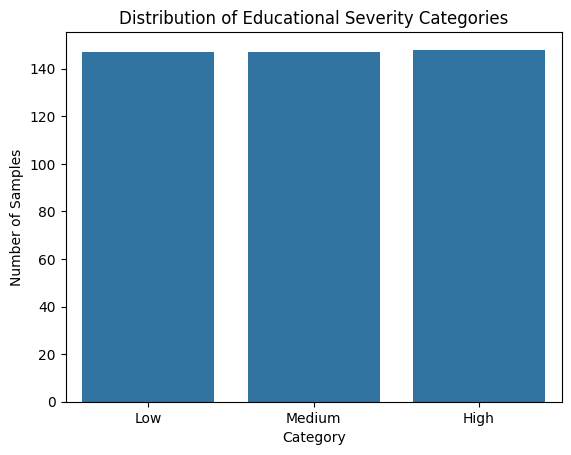


5. FEATURES
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Training samples: 353
Testing samples: 89

6. MODEL TRAINED SUCCESSFULLY

7. ACCURACY
Accuracy: 0.4157

8. CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       0.57      0.53      0.55        30
         Low       0.52      0.47      0.49        30
      Medium       0.21      0.24      0.22        29

    accuracy                           0.42        89
   macro avg       0.43      0.41      0.42        89
weighted avg       0.43      0.42      0.42        89



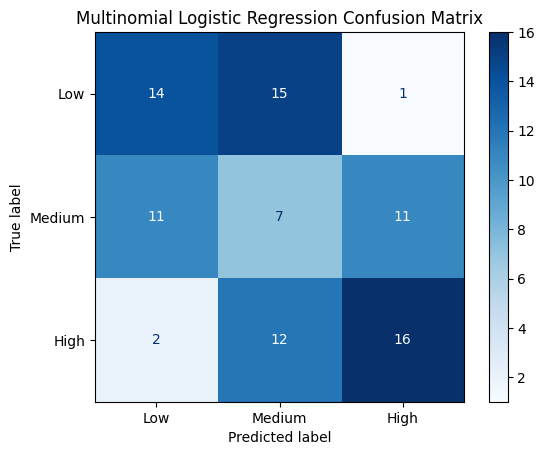


9. SAMPLE PREDICTIONS


,Actual Category,Predicted Category
121,Medium,High
348,Medium,Low
355,Low,Low
81,Low,Medium
39,Low,Medium
82,Low,Low
317,High,Medium
433,Low,Low
169,Medium,High
387,High,Low



10. CONCLUSION
A multinomial logistic regression model was trained.
The continuous dataset target was divided into three
educational categories: Low, Medium, and High.
The model was evaluated using accuracy and a classification report.
Predictions saved to diabetes_severity_predictions.csv

Note: These categories are for educational ML practice,
not medical severity classifications or clinical diagnoses.


In [1]:

# PROGRAM 6: DIABETES SEVERITY - MULTINOMIAL LOGISTIC REGRESSION

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print("=" * 70)
print("DIABETES SEVERITY - MULTINOMIAL LOGISTIC REGRESSION")
print("=" * 70)

# 2. Load Dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print("\n1. DATASET LOADED")
print("Dataset shape:", df.shape)
display(df.head())

# 3. Understand the Dataset
print("\n2. DATASET INFORMATION")
df.info()

print("\n3. STATISTICAL SUMMARY")
display(df.describe())

# 4. Create Three Educational Target Categories
# The original target is a continuous disease-progression measure.
# These categories are created only for this ML exercise.
df["severity"] = pd.qcut(
    df["target"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("\n4. EDUCATIONAL CATEGORY DISTRIBUTION")
print(df["severity"].value_counts())

sns.countplot(data=df, x="severity", order=["Low", "Medium", "High"])
plt.title("Distribution of Educational Severity Categories")
plt.xlabel("Category")
plt.ylabel("Number of Samples")
plt.show()

# 5. Prepare Features and Target
X = df.drop(columns=["target", "severity"])
y = df["severity"]

print("\n5. FEATURES")
print(list(X.columns))

# 6. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

# 7. Build Multinomial Logistic Regression Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=3000
    ))
])

# 8. Train Model
model.fit(X_train, y_train)
print("\n6. MODEL TRAINED SUCCESSFULLY")

# 9. Predictions
y_pred = model.predict(X_test)

print("\n7. ACCURACY")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n8. CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, zero_division=0))

# 10. Confusion Matrix
cm = confusion_matrix(
    y_test, y_pred, labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)
disp.plot(cmap="Blues")
plt.title("Multinomial Logistic Regression Confusion Matrix")
plt.show()

# 11. Compare Actual and Predicted Categories
comparison = pd.DataFrame({
    "Actual Category": y_test,
    "Predicted Category": y_pred
})
print("\n9. SAMPLE PREDICTIONS")
display(comparison.head(10))

# 12. Save Results
comparison.to_csv("diabetes_severity_predictions.csv", index=False)

print("\n10. CONCLUSION")
print("A multinomial logistic regression model was trained.")
print("The continuous dataset target was divided into three")
print("educational categories: Low, Medium, and High.")
print("The model was evaluated using accuracy and a classification report.")
print("Predictions saved to diabetes_severity_predictions.csv")
print("\nNote: These categories are for educational ML practice,")
print("not medical severity classifications or clinical diagnoses.")